In [178]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset = pd.read_excel("HousePricePrediction.xlsx")

print(dataset.head(5))

   Id  MSSubClass MSZoning  LotArea LotConfig BldgType  OverallCond  \
0   0          60       RL     8450    Inside     1Fam            5   
1   1          20       RL     9600       FR2     1Fam            8   
2   2          60       RL    11250    Inside     1Fam            5   
3   3          70       RL     9550    Corner     1Fam            5   
4   4          60       RL    14260       FR2     1Fam            5   

   YearBuilt  YearRemodAdd Exterior1st  BsmtFinSF2  TotalBsmtSF  SalePrice  
0       2003          2003     VinylSd         0.0        856.0   208500.0  
1       1976          1976     MetalSd         0.0       1262.0   181500.0  
2       2001          2002     VinylSd         0.0        920.0   223500.0  
3       1915          1970     Wd Sdng         0.0        756.0   140000.0  
4       2000          2000     VinylSd         0.0       1145.0   250000.0  


In [195]:
dataset.shape

(2919, 12)

In [211]:
obj = (dataset.dtypes == 'object')
object_cols = list(obj[obj].index)
print("Categorical variables:",len(object_cols))

int_ = (dataset.dtypes == 'int')
num_cols = list(int_[int_].index)
print("Integer variables:",len(num_cols))

fl = (dataset.dtypes == 'float')
fl_cols = list(fl[fl].index)
print("Float variables:",len(fl_cols))

Categorical variables: 0
Integer variables: 5
Float variables: 3


<Axes: >

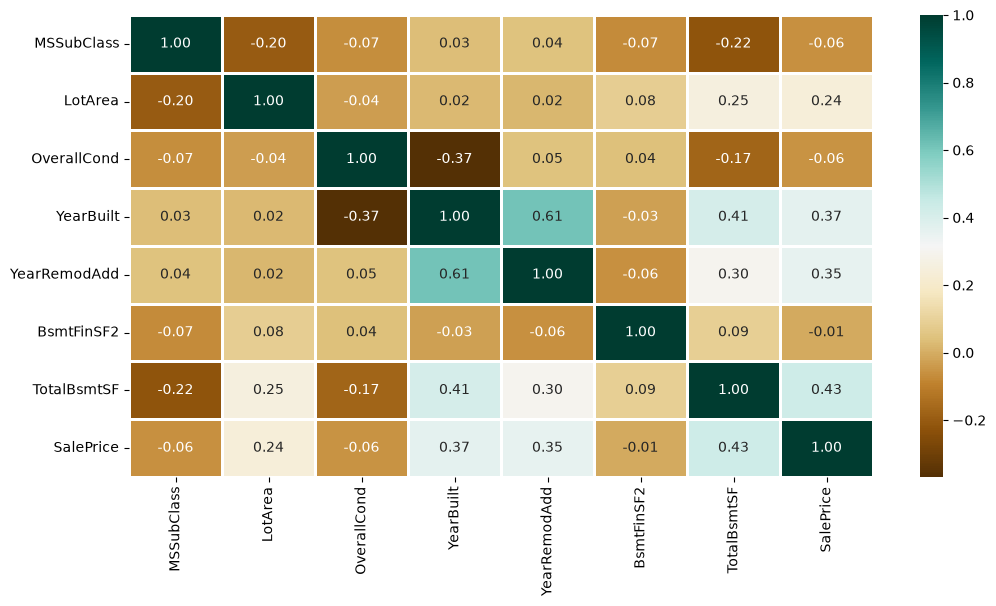

In [226]:
numerical_dataset = dataset.select_dtypes(include=['number'])

plt.figure(figsize=(12, 6))
sns.heatmap(numerical_dataset.corr(),
            cmap = 'BrBG',
            fmt = '.2f',
            linewidths = 2,
            annot = True)

<Axes: title={'center': 'No. Unique values of Categorical Features'}>

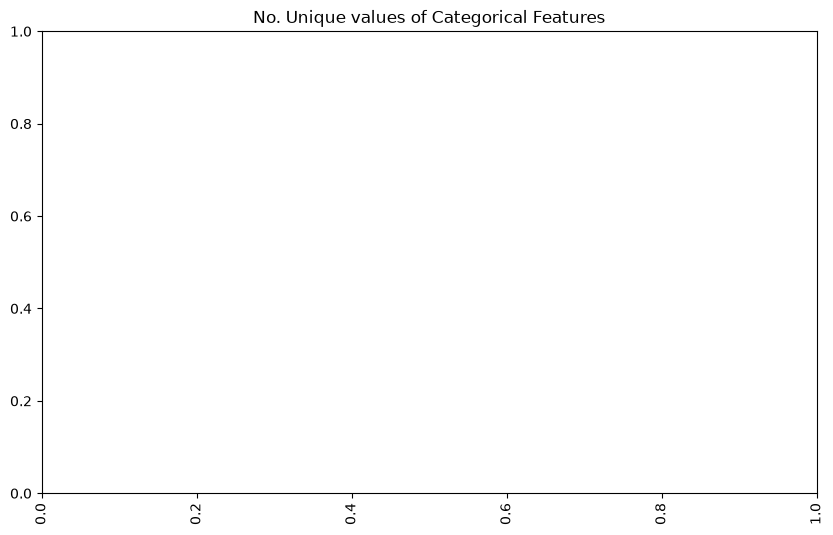

In [240]:
unique_values = []
for col in object_cols:
  unique_values.append(dataset[col].unique().size)
plt.figure(figsize=(10,6))
plt.title('No. Unique values of Categorical Features')
plt.xticks(rotation=90)
sns.barplot(x=object_cols,y=unique_values)


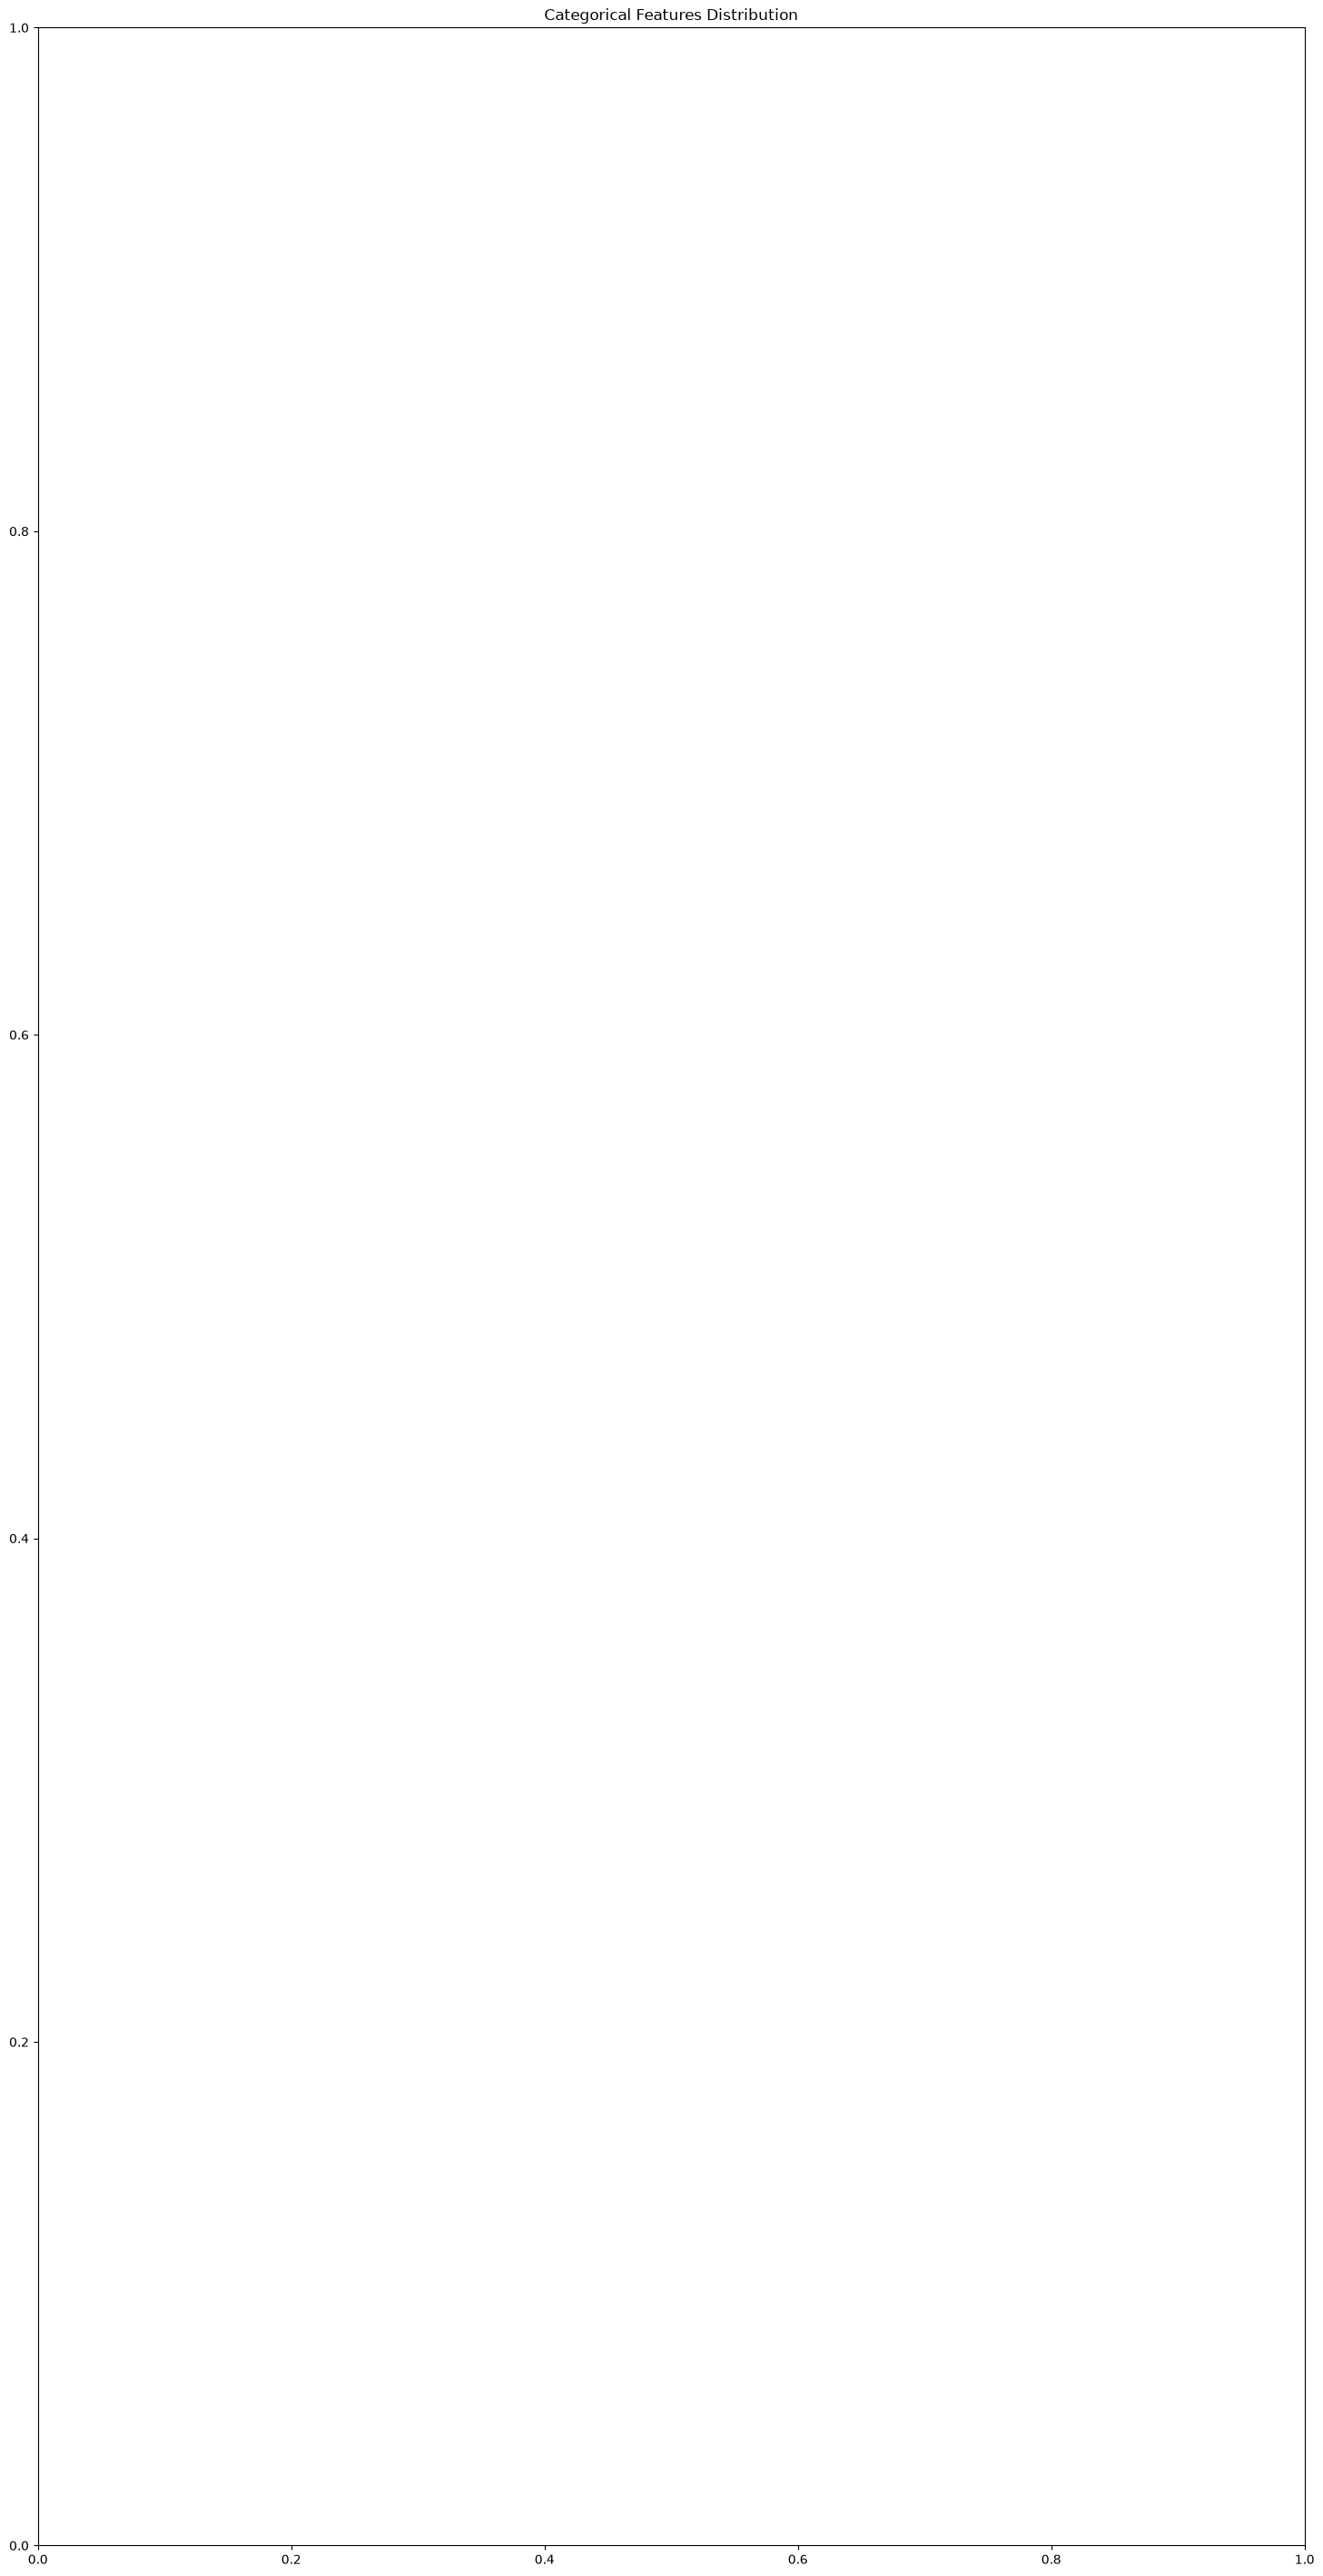

In [253]:
plt.figure(figsize=(18, 36))
plt.title('Categorical Features Distribution')
index = 1

for col in object_cols:
    y = dataset[col].value_counts()
    plt.subplot(11, 4, index)
    plt.xticks(rotation=90)
    sns.barplot(x=y.index, y=y.values)
    plt.xlabel(col)
    plt.ylabel("Count")
    index += 1


In [254]:
dataset.drop(['Id'], axis=1, inplace=True, errors='ignore')


In [255]:
dataset['SalePrice'] = dataset['SalePrice'].fillna(
  dataset['SalePrice'].mean())

In [256]:
new_dataset = dataset.dropna()

In [257]:
new_dataset.isnull().sum()

MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

In [258]:
from sklearn.preprocessing import OneHotEncoder

s = (new_dataset.dtypes == 'object')
object_cols = list(s[s].index)
print("Categorical variables:")
print(object_cols)
print('No. of. categorical features: ',
      len(object_cols))

Categorical variables:
[]
No. of. categorical features:  0


In [259]:
OH_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
OH_cols = pd.DataFrame(OH_encoder.fit_transform(new_dataset[object_cols]))
OH_cols.index = new_dataset.index
OH_cols.columns = OH_encoder.get_feature_names_out()
df_final = new_dataset.drop(object_cols, axis=1)
df_final = pd.concat([df_final, OH_cols], axis=1)

In [260]:
from sklearn.model_selection import train_test_split

df_encoded = pd.get_dummies(df_final)

X = df_encoded.drop(['SalePrice'], axis=1)
Y = df_encoded['SalePrice']

X_train, X_valid, Y_train, Y_valid = train_test_split(
    X, Y, train_size=0.8, test_size=0.2, random_state=0
)


In [261]:
from sklearn import svm
from sklearn.metrics import mean_absolute_percentage_error

model_SVR = svm.SVR()
model_SVR.fit(X_train,Y_train)
Y_pred = model_SVR.predict(X_valid)

print(mean_absolute_percentage_error(Y_valid, Y_pred))

0.1870512931870423


In [262]:
from sklearn.ensemble import RandomForestRegressor

model_RFR = RandomForestRegressor(n_estimators=10)
model_RFR.fit(X_train, Y_train)
Y_pred = model_RFR.predict(X_valid)

mean_absolute_percentage_error(Y_valid, Y_pred)

0.18306853446001184

In [263]:
from sklearn.linear_model import LinearRegression

model_LR = LinearRegression()
model_LR.fit(X_train, Y_train)
Y_pred = model_LR.predict(X_valid)

print(mean_absolute_percentage_error(Y_valid, Y_pred))

0.187416838415999


## Production Inference Pipeline
This iteration moves past static evaluation loops. By preserving the transformation maps from our `OneHotEncoder` setup, the pipeline can now ingest single raw property profiles, vectorize the categorical metrics, align them with our training sequence layouts (`X_train.columns`), and feed them directly into the optimized `Random Forest Regressor` for on-demand predictions.

In [264]:
import pandas as pd
import numpy as np

custom_house = {
    'MSSubClass': 60,
    'MSZoning': 'RL',
    'LotArea': 9500,
    'LotConfig': 'Inside',
    'BldgType': '1Fam',
    'OverallCond': 5,
    'YearBuilt': 2005,
    'YearRemodAdd': 2008,
    'Exterior1st': 'VinylSd',
    'BsmtFinSF2': 0.0,
    'TotalBsmtSF': 1100.0
}
custom_df = pd.DataFrame([custom_house])

custom_final = pd.get_dummies(custom_df)

custom_final = custom_final.reindex(columns=X_train.columns, fill_value=0)

predicted_price = model_RFR.predict(custom_final)[0]

print("Custom Input Features Successfully Processed!")
print(f"Predicted Real Estate Market Value: ${predicted_price:,.2f}")


Custom Input Features Successfully Processed!
Predicted Real Estate Market Value: $262,456.02
